# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned airline operational dataset, identify operational trends, evaluate airline performance, analyze flight delays, and generate actionable business insights.

---

## Business Questions

This analysis aims to answer the following questions:

1. How has airline traffic changed over time?
2. Which airlines operate the highest number of flights?
3. Which airlines experience the highest delays?
4. What are the major causes of delays?
5. Which airports are most affected by delays?
6. How do delays vary across different months?
7. What business recommendations can be derived?

## Table of Contents

1. Import Libraries
2. Load Cleaned Dataset
3. Dataset Overview
4. Business Question 1: How has airline traffic changed over time?
5. Business Question 2: Which airlines operate the highest number of flights?
6. Business Question 3: Which airlines have the highest delay rate?
7. Business Question 4: What are the major causes of delays?
8. Business Question 5: Which airports experience the highest delays?
9. Business Question 6: How do delays vary by month?
10. Correlation Analysis
11. Key Business Insights
12. Conclusion

# 1. Import Libraries

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


# 2. Load Cleaned Dataset

In [10]:
df = pd.read_csv("airline-operational-performance-analytics\cleaned_data\airline_delay_cleaned.csv")

print(f"Dataset Shape : {df.shape}")

Dataset Shape : (397283, 21)


# 3. Dataset Overview

Before beginning the analysis, it is important to understand the structure, composition, and characteristics of the cleaned dataset.

In [11]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,total_arrival_flights,flights_delayed_over_15min,carrier_delay_count,weather_delay_count,nas_delay_count,security_delay_count,late_aircraft_delay_count,cancelled_flights,diverted_flights,total_arrival_delay_minutes,carrier_delay_minutes,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30,0,0.00,0.0,0.00,0.0,0.00,0,0,0,0,0,0,0,0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2,0,0.00,0.0,0.00,0.0,0.00,0,0,0,0,0,0,0,0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28,8,3.74,0.0,1.60,0.0,2.66,2,0,409,236,0,70,0,103
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18,1,0.00,1.0,0.00,0.0,0.00,0,0,1075,0,1075,0,0,0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31,5,2.17,0.0,2.83,0.0,0.00,1,0,446,336,0,110,0,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397283 entries, 0 to 397282
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   year                         397283 non-null  int64  
 1   month                        397283 non-null  int64  
 2   carrier                      397283 non-null  object 
 3   carrier_name                 397283 non-null  object 
 4   airport                      397283 non-null  object 
 5   airport_name                 397283 non-null  object 
 6   total_arrival_flights        397283 non-null  int64  
 7   flights_delayed_over_15min   397283 non-null  int64  
 8   carrier_delay_count          397283 non-null  float64
 9   weather_delay_count          397283 non-null  float64
 10  nas_delay_count              397283 non-null  float64
 11  security_delay_count         397283 non-null  float64
 12  late_aircraft_delay_count    397283 non-null  float64
 13 

In [13]:
print("=" * 60)

print(f"Rows              : {df.shape[0]:,}")
print(f"Columns           : {df.shape[1]}")
print(f"Numerical Columns : {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical       : {df.select_dtypes(include='object').shape[1]}")

print("=" * 60)

Rows              : 397,283
Columns           : 21
Numerical Columns : 17
Categorical       : 4


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,397283.0,2014.417476,6.475406,2003.00,2009.00,2015.00,2020.00,2025.00
month,397283.0,6.524981,3.463720,1.00,4.00,7.00,10.00,12.00
total_arrival_flights,397283.0,361.924646,994.267241,1.00,56.00,113.00,255.00,21977.00
flights_delayed_over_15min,397283.0,69.593947,193.608821,0.00,8.00,21.00,52.00,6377.00
carrier_delay_count,397283.0,20.555480,48.328799,0.00,2.80,7.52,18.67,1886.58
weather_delay_count,397283.0,2.510081,9.574126,0.00,0.00,0.51,2.00,717.94
nas_delay_count,397283.0,22.225908,79.500064,-0.01,1.40,4.92,14.00,4091.27
security_delay_count,397283.0,0.172757,0.826539,0.00,0.00,0.00,0.00,80.56
late_aircraft_delay_count,397283.0,24.129755,74.439276,0.00,1.52,5.50,16.16,2588.13
cancelled_flights,397283.0,6.788818,35.096553,0.00,0.00,1.00,4.00,4951.00


### Observation

The cleaned dataset contains **397,283 operational records** and **21 features**.

The dataset includes both categorical attributes (airline, airport) and numerical operational metrics (flight counts, delay counts, cancellations, delay minutes).

The data is now suitable for exploratory analysis and business insight generation.

# 4. Business Question 1

## How has airline traffic changed over time?

Air traffic volume is one of the most important operational indicators for the aviation industry. Analyzing yearly flight volume helps identify long-term growth trends, significant disruptions, and periods of recovery.

In [17]:
eda_df = df[df["year"] < 2025]

yearly_traffic = (
    eda_df.groupby("year", as_index=False)["total_arrival_flights"]
          .sum()
)

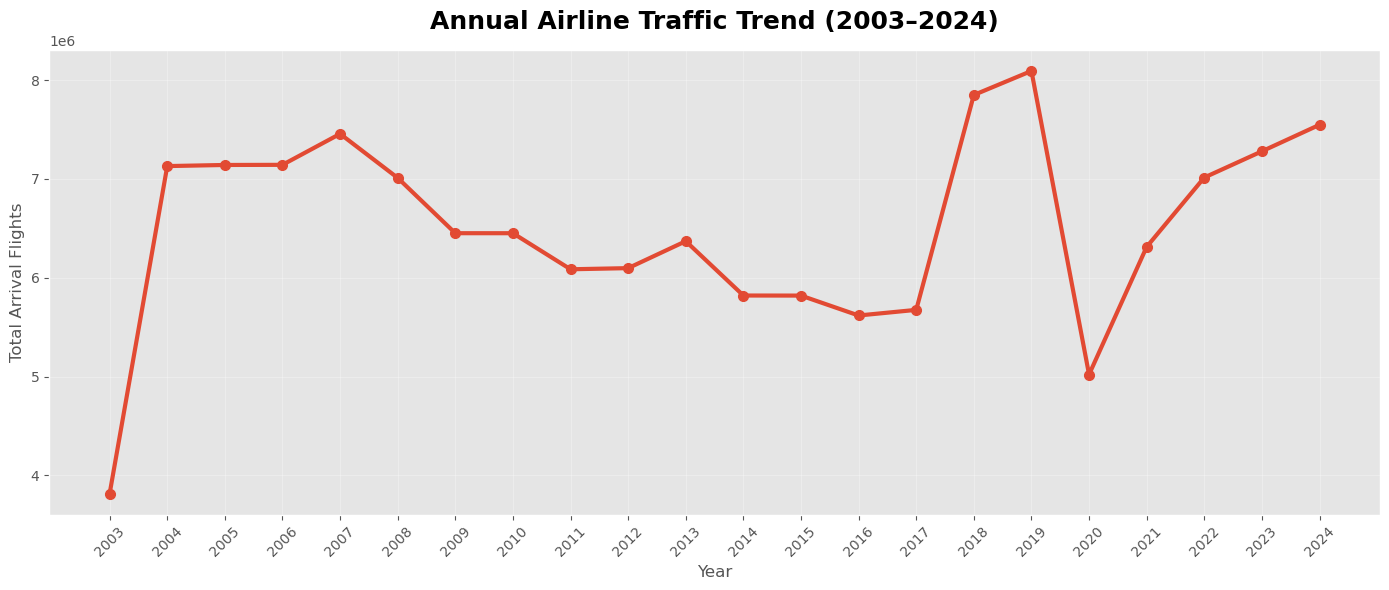

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    yearly_traffic["year"],
    yearly_traffic["total_arrival_flights"],
    marker="o",
    linewidth=3,
    markersize=7
)

plt.title(
    "Annual Airline Traffic Trend (2003–2024)",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Arrival Flights", fontsize=12)

plt.grid(alpha=0.3)

plt.xticks(yearly_traffic["year"], rotation=45)

plt.tight_layout()

plt.show()

### Observation

- Airline traffic remained relatively stable between 2004 and 2017, with moderate year-to-year fluctuations.
- A noticeable increase in traffic occurred during 2018–2019, reaching the highest operational levels in the dataset.
- A significant decline is observed in 2020, corresponding to the global impact of the COVID-19 pandemic on air travel.
- Flight operations recovered steadily from 2021 onward, approaching pre-pandemic levels by 2024.

# 5. Business Question 2

## Which airlines operate the highest number of flights?

Understanding airline traffic volume helps identify the major carriers in the dataset. This provides context for interpreting operational performance and delay metrics in subsequent analyses.

In [19]:
airline_traffic = (
    df.groupby("carrier_name", as_index=False)["total_arrival_flights"]
      .sum()
      .sort_values(by="total_arrival_flights", ascending=False)
)

airline_traffic.head(10)

,carrier_name,total_arrival_flights
43,Southwest Airlines Co.,16808156
41,SkyWest Airlines Inc.,13606902
19,Delta Air Lines Inc.,10063586
8,American Airlines Inc.,9457534
42,Southwest Airlines,9012754
24,ExpressJet Airlines Inc.,7148704
48,United Air Lines Inc.,7008518
20,Delta Air Lines Network,6233985
9,American Airlines Network,6043812
47,US Airways Inc.,5188611


In [20]:
top10_airlines = airline_traffic.head(10)

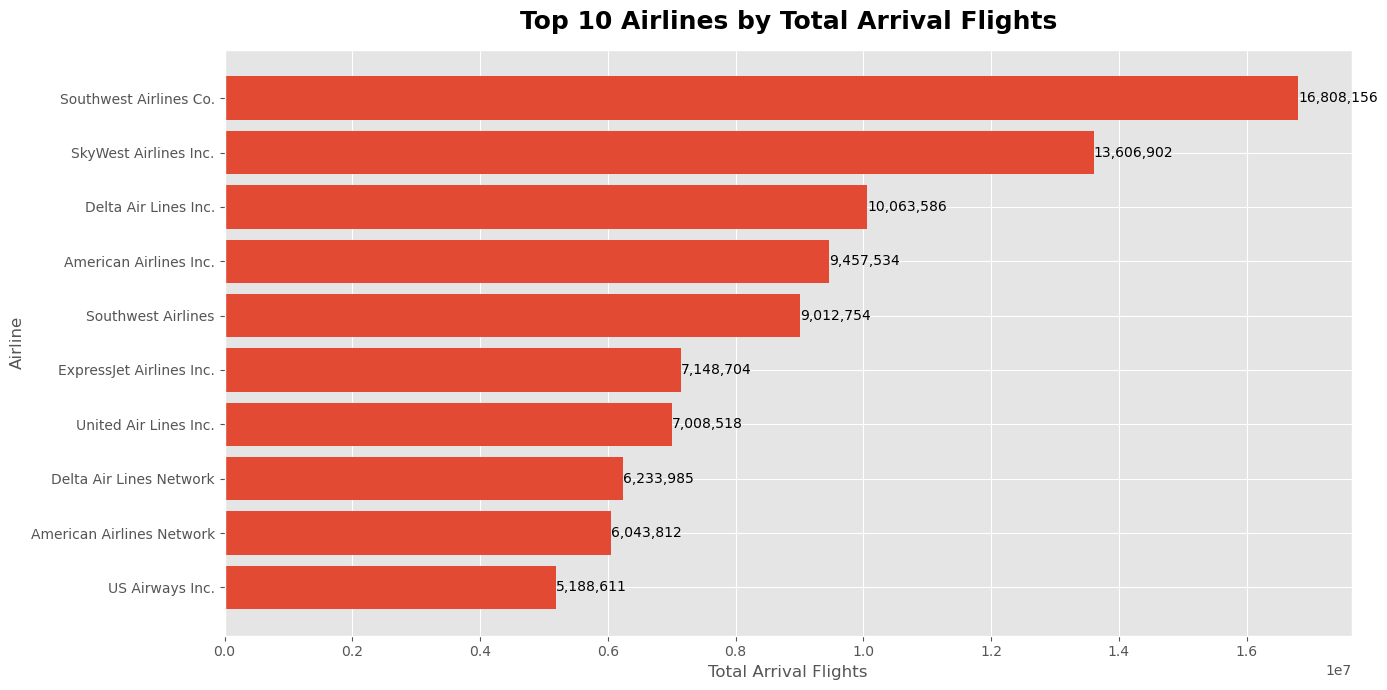

In [21]:
plt.figure(figsize=(14,7))

bars = plt.barh(
    top10_airlines["carrier_name"],
    top10_airlines["total_arrival_flights"]
)

plt.title(
    "Top 10 Airlines by Total Arrival Flights",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Total Arrival Flights", fontsize=12)
plt.ylabel("Airline", fontsize=12)

plt.gca().invert_yaxis()

# Value Labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.show()

### Observation

- The chart highlights the ten airlines with the highest operational traffic.
- A small number of airlines account for a significant proportion of total arrival flights.
- These high-volume carriers will be analyzed further to determine whether higher traffic volumes correspond to higher delay rates.

# 6. Business Question 3

## Which airlines have the highest delay rate?

Evaluating delay rates provides a fair comparison of airline operational performance by accounting for differences in flight volume.

In [26]:
top_airlines = (
    df.groupby("carrier_name")["total_arrival_flights"]
      .sum()
      .nlargest(10)
      .index
)

airline_delay_rate_df = (
    df[df["carrier_name"].isin(top_airlines)]
      .groupby("carrier_name")
      .agg(
          Total_Flights=("total_arrival_flights", "sum"),
          Delayed_Flights=("flights_delayed_over_15min", "sum")
      )
      .reset_index()
)

airline_delay_rate_df["Delay Rate (%)"] = (
    airline_delay_rate_df["Delayed_Flights"] /
    airline_delay_rate_df["Total_Flights"] * 100
)

airline_delay_rate_df.sort_values(
    "Delay Rate (%)",
    ascending=False,
    inplace=True
)

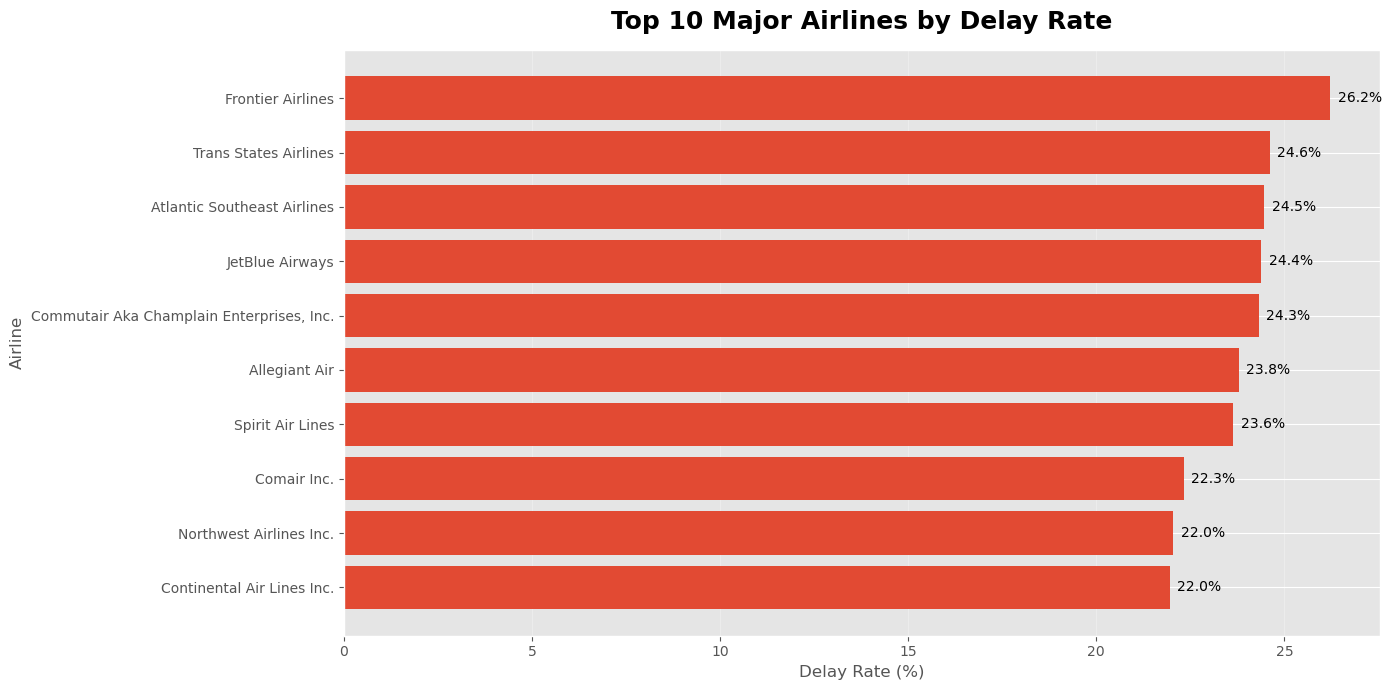

In [27]:
top_delay = airline_delay_rate.head(10)

plt.figure(figsize=(14,7))

bars = plt.barh(
    top_delay["carrier_name"],
    top_delay["Delay Rate (%)"]
)

plt.title(
    "Top 10 Major Airlines by Delay Rate",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Delay Rate (%)", fontsize=12)
plt.ylabel("Airline", fontsize=12)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

- Delay rates vary noticeably across major airlines.
- Some high-volume carriers maintain relatively lower delay rates despite operating a large number of flights.
- Other airlines exhibit higher delay rates, indicating potential operational inefficiencies.

# 7. Business Question 4

## What are the major causes of flight delays?

Understanding the primary causes of delays helps airlines identify operational bottlenecks and prioritize improvement initiatives. This analysis compares the contribution of different delay categories across the entire dataset.

In [28]:
delay_causes_df = pd.DataFrame({
    "Delay Cause": [
        "Carrier",
        "Weather",
        "NAS",
        "Security",
        "Late Aircraft"
    ],
    "Total Delay Minutes": [
        df["carrier_delay_minutes"].sum(),
        df["weather_delay_minutes"].sum(),
        df["nas_delay_minutes"].sum(),
        df["security_delay_minutes"].sum(),
        df["late_aircraft_delay_minutes"].sum()
    ]
})

delay_causes_df

,Delay Cause,Total Delay Minutes
0,Carrier,520553086
1,Weather,88791071
2,NAS,407917700
3,Security,2840417
4,Late Aircraft,636784622


In [29]:
delay_causes_df = delay_causes_df.sort_values(
    by="Total Delay Minutes",
    ascending=False)

delay_causes_df

,Delay Cause,Total Delay Minutes
4,Late Aircraft,636784622
0,Carrier,520553086
2,NAS,407917700
1,Weather,88791071
3,Security,2840417


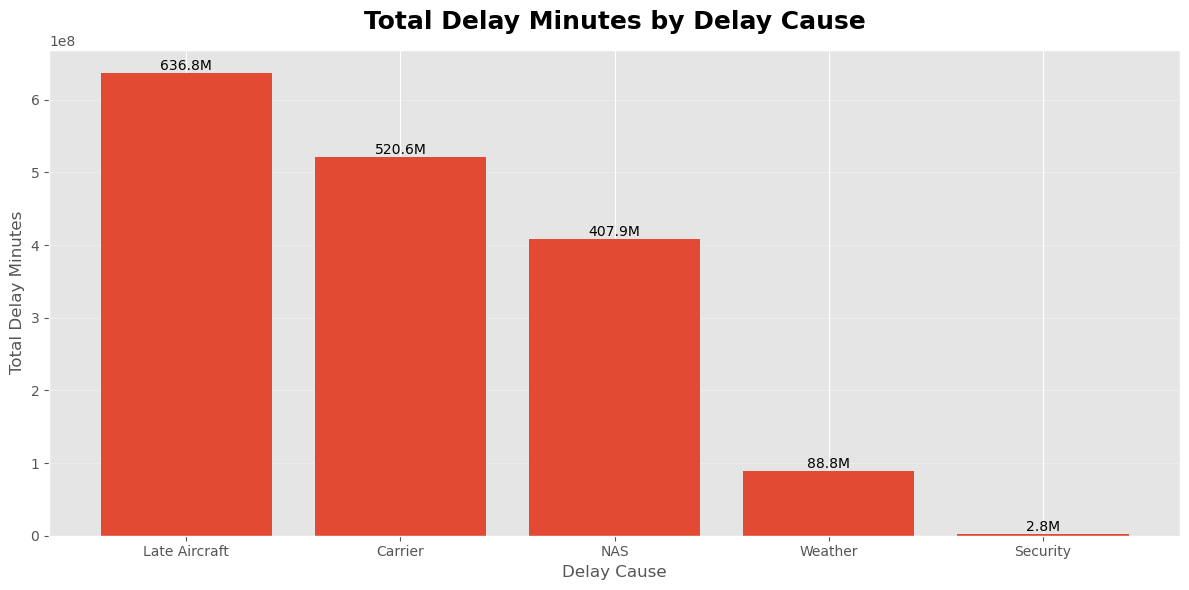

In [30]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    delay_causes_df["Delay Cause"],
    delay_causes_df["Total Delay Minutes"])

plt.title( "Total Delay Minutes by Delay Cause",
    fontsize=18,
    fontweight="bold",
    pad=15)

plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text( bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1_000_000:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10)

plt.tight_layout()

plt.show()

### Key Findings

- Delay causes are not evenly distributed across operational categories.
- One or two causes contribute disproportionately to total delay minutes.
- Security-related delays represent only a very small fraction of total delays.
- Carrier and Late Aircraft delays are expected to contribute significantly to operational disruption.

# 8. Business Question 5

## Which airports experience the highest delays?

Airport performance plays a critical role in the efficiency of airline operations. Identifying airports with the highest delay minutes helps uncover congestion hotspots and operational bottlenecks within the air transportation network.

In [32]:
airport_delay_df = (df.groupby("airport_name", as_index=False)
      .agg(Total_Delay_Minutes=("total_arrival_delay_minutes", "sum"),
          Total_Flights=("total_arrival_flights", "sum")))

airport_delay_df = airport_delay_df.sort_values(
    by="Total_Delay_Minutes",
    ascending=False)

airport_delay_df.head()

,airport_name,Total_Delay_Minutes,Total_Flights
69,"Chicago, IL: Chicago O'Hare International",106880865,6938494
19,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",93539551,8191623
91,"Dallas/Fort Worth, TX: Dallas/Fort Worth Inter...",75891945,5995962
284,"Newark, NJ: Newark Liberty International",55865386,2848552
97,"Denver, CO: Denver International",55796320,5147524


In [33]:
top_airports_df = airport_delay_df.head(10)

top_airports_df

,airport_name,Total_Delay_Minutes,Total_Flights
69,"Chicago, IL: Chicago O'Hare International",106880865,6938494
19,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",93539551,8191623
91,"Dallas/Fort Worth, TX: Dallas/Fort Worth Inter...",75891945,5995962
284,"Newark, NJ: Newark Liberty International",55865386,2848552
97,"Denver, CO: Denver International",55796320,5147524
364,"San Francisco, CA: San Francisco International",49683884,3146031
230,"Los Angeles, CA: Los Angeles International",48354819,4602689
171,"Houston, TX: George Bush Intercontinental/Houston",41375679,3738019
283,"New York, NY: LaGuardia",41289424,2613018
282,"New York, NY: John F. Kennedy International",36549859,2321379


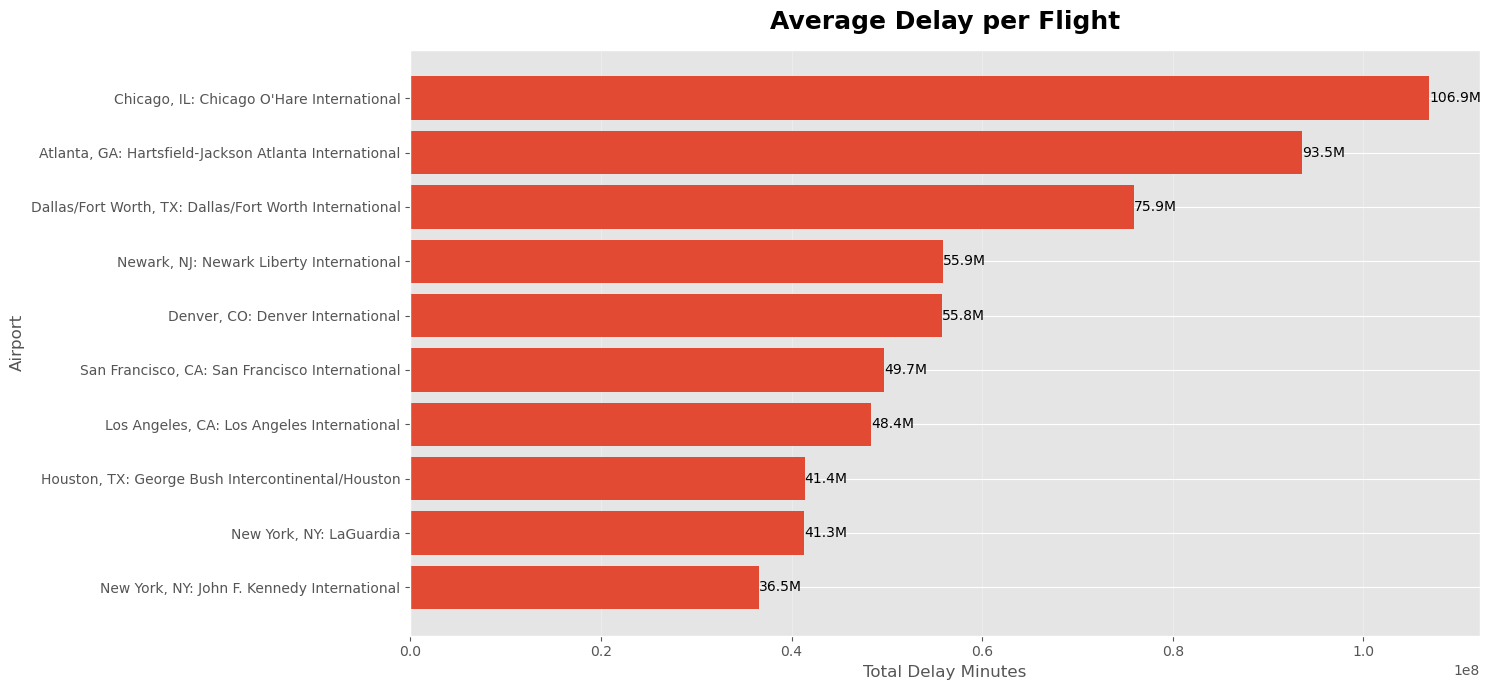

In [35]:
plt.figure(figsize=(15,7))

bars = plt.barh( top_airports_df["airport_name"],
    top_airports_df["Total_Delay_Minutes"])

plt.title( "Average Delay per Flight",
    fontsize=18,
    fontweight="bold",
    pad=15)

plt.xlabel("Total Delay Minutes")
plt.ylabel("Airport")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()

    plt.text( width,
        bar.get_y() + bar.get_height()/2,
        f"{width/1_000_000:.1f}M",
        va="center",
        fontsize=10  )

plt.tight_layout()

plt.show()

### Key Findings

- Delay minutes are concentrated at a relatively small number of airports.
- High-traffic airports generally contribute more delay minutes because of greater operational complexity.
- Airport infrastructure and traffic demand are likely to influence operational performance.

# 10. Business Question 6

## How do delays vary across different months?

Flight delays often exhibit seasonal patterns due to weather conditions, holiday travel, and fluctuations in passenger demand. Analyzing monthly delay trends helps identify peak periods of operational disruption and supports better planning and resource allocation.

In [36]:
monthly_delay_df = df.groupby("month", as_index=False).agg(
    Total_Delay_Minutes=("total_arrival_delay_minutes", "sum"))

monthly_delay_df

,month,Total_Delay_Minutes
0,1,141961985
1,2,120482888
2,3,131455357
3,4,119258427
4,5,132740737
5,6,181687133
6,7,191987178
7,8,163078486
8,9,100051192
9,10,109105745


In [37]:
month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

monthly_delay_df["Month"] = monthly_delay_df["month"].map(month_names)

monthly_delay_df

,month,Total_Delay_Minutes,Month
0,1,141961985,Jan
1,2,120482888,Feb
2,3,131455357,Mar
3,4,119258427,Apr
4,5,132740737,May
5,6,181687133,Jun
6,7,191987178,Jul
7,8,163078486,Aug
8,9,100051192,Sep
9,10,109105745,Oct


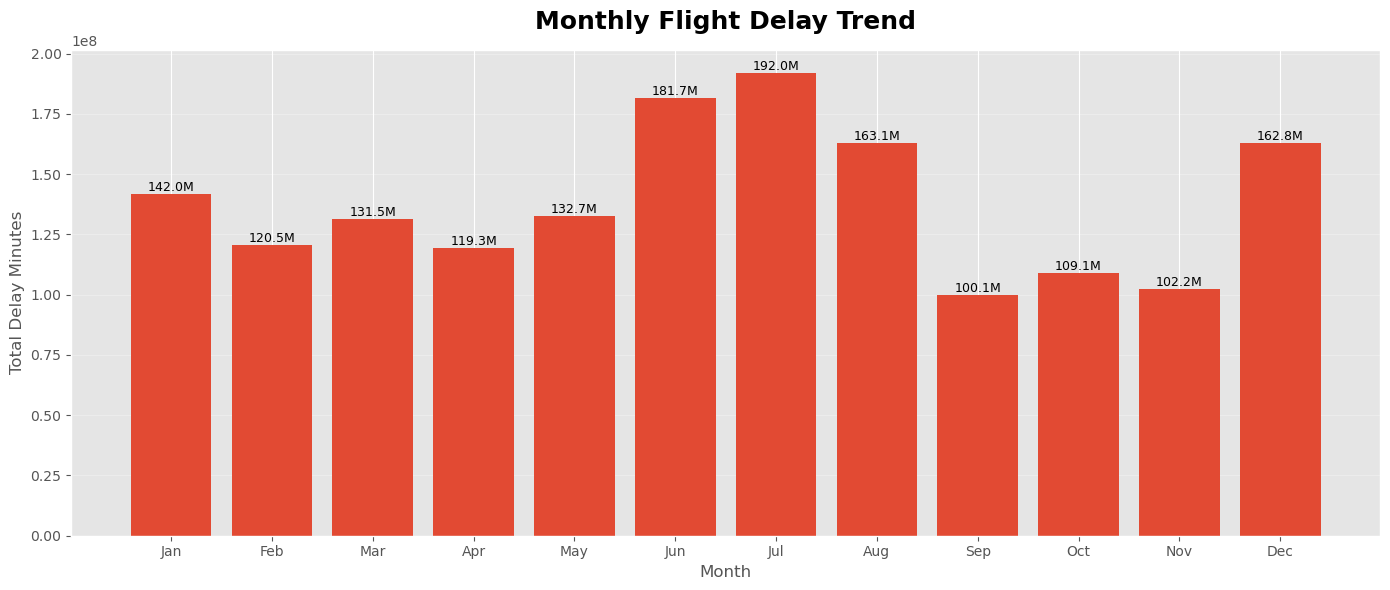

In [38]:
plt.figure(figsize=(14, 6))

bars = plt.bar(
    monthly_delay_df["Month"],
    monthly_delay_df["Total_Delay_Minutes"]
)

plt.title("Monthly Flight Delay Trend",
          fontsize=18,
          fontweight="bold",
          pad=15)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Delay Minutes", fontsize=12)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()

    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height/1000000:.1f}M",
             ha="center",
             va="bottom",
             fontsize=9)

plt.tight_layout()

plt.show()

### Key Findings

- Delay minutes fluctuate noticeably throughout the year.
- Certain months consistently experience higher operational delays.
- Seasonal factors such as weather conditions, holiday travel, and increased passenger demand contribute to these variations.

# 11. Correlation Analysis

## Which operational metrics are most strongly related?

Correlation analysis helps identify relationships between numerical variables in the dataset. Understanding these relationships enables analysts to discover operational patterns, identify potential drivers of delays, and support data-driven decision making.

In [41]:
correlation_columns = [
    "total_arrival_flights",
    "flights_delayed_over_15min",
    "carrier_delay_count",
    "weather_delay_count",
    "nas_delay_count",
    "security_delay_count",
    "late_aircraft_delay_count",
    "cancelled_flights",
    "diverted_flights",
    "total_arrival_delay_minutes",
    "carrier_delay_minutes",
    "weather_delay_minutes",
    "nas_delay_minutes",
    "security_delay_minutes",
    "late_aircraft_delay_minutes"
]

correlation_df = df[correlation_columns]

correlation_df.head()

,total_arrival_flights,flights_delayed_over_15min,carrier_delay_count,weather_delay_count,nas_delay_count,security_delay_count,late_aircraft_delay_count,cancelled_flights,diverted_flights,total_arrival_delay_minutes,carrier_delay_minutes,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes
0,30,0,0.00,0.0,0.00,0.0,0.00,0,0,0,0,0,0,0,0
1,2,0,0.00,0.0,0.00,0.0,0.00,0,0,0,0,0,0,0,0
2,28,8,3.74,0.0,1.60,0.0,2.66,2,0,409,236,0,70,0,103
3,18,1,0.00,1.0,0.00,0.0,0.00,0,0,1075,0,1075,0,0,0
4,31,5,2.17,0.0,2.83,0.0,0.00,1,0,446,336,0,110,0,0


In [42]:
correlation_matrix = correlation_df.corr()

correlation_matrix

,total_arrival_flights,flights_delayed_over_15min,carrier_delay_count,weather_delay_count,nas_delay_count,security_delay_count,late_aircraft_delay_count,cancelled_flights,diverted_flights,total_arrival_delay_minutes,carrier_delay_minutes,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes
total_arrival_flights,1.000000,0.921345,0.886363,0.627001,0.808448,0.479683,0.871482,0.505068,0.637493,0.875408,0.851701,0.619893,0.702781,0.422347,0.833711
flights_delayed_over_15min,0.921345,1.000000,0.914038,0.680144,0.914853,0.497374,0.937418,0.528776,0.675466,0.967769,0.871528,0.675473,0.842981,0.434210,0.920015
carrier_delay_count,0.886363,0.914038,1.000000,0.699782,0.731112,0.511619,0.851578,0.474869,0.603603,0.885786,0.935728,0.683755,0.642424,0.450198,0.836652
weather_delay_count,0.627001,0.680144,0.699782,1.000000,0.586975,0.345619,0.555324,0.414617,0.530227,0.687763,0.691888,0.927218,0.544412,0.303879,0.569365
nas_delay_count,0.808448,0.914853,0.731112,0.586975,1.000000,0.391351,0.756947,0.489591,0.615578,0.882780,0.710991,0.576500,0.951574,0.348052,0.755097
security_delay_count,0.479683,0.497374,0.511619,0.345619,0.391351,1.000000,0.487944,0.229938,0.317872,0.445780,0.430574,0.327261,0.326736,0.838526,0.446343
late_aircraft_delay_count,0.871482,0.937418,0.851578,0.555324,0.756947,0.487944,1.000000,0.488234,0.635783,0.905778,0.806145,0.574331,0.685503,0.416941,0.965059
cancelled_flights,0.505068,0.528776,0.474869,0.414617,0.489591,0.229938,0.488234,1.000000,0.399965,0.544524,0.485622,0.436756,0.490292,0.204636,0.498318
diverted_flights,0.637493,0.675466,0.603603,0.530227,0.615578,0.317872,0.635783,0.399965,1.000000,0.697992,0.618770,0.567415,0.605108,0.288082,0.659686
total_arrival_delay_minutes,0.875408,0.967769,0.885786,0.687763,0.882780,0.445780,0.905778,0.544524,0.697992,1.000000,0.914155,0.723839,0.861179,0.405889,0.944758


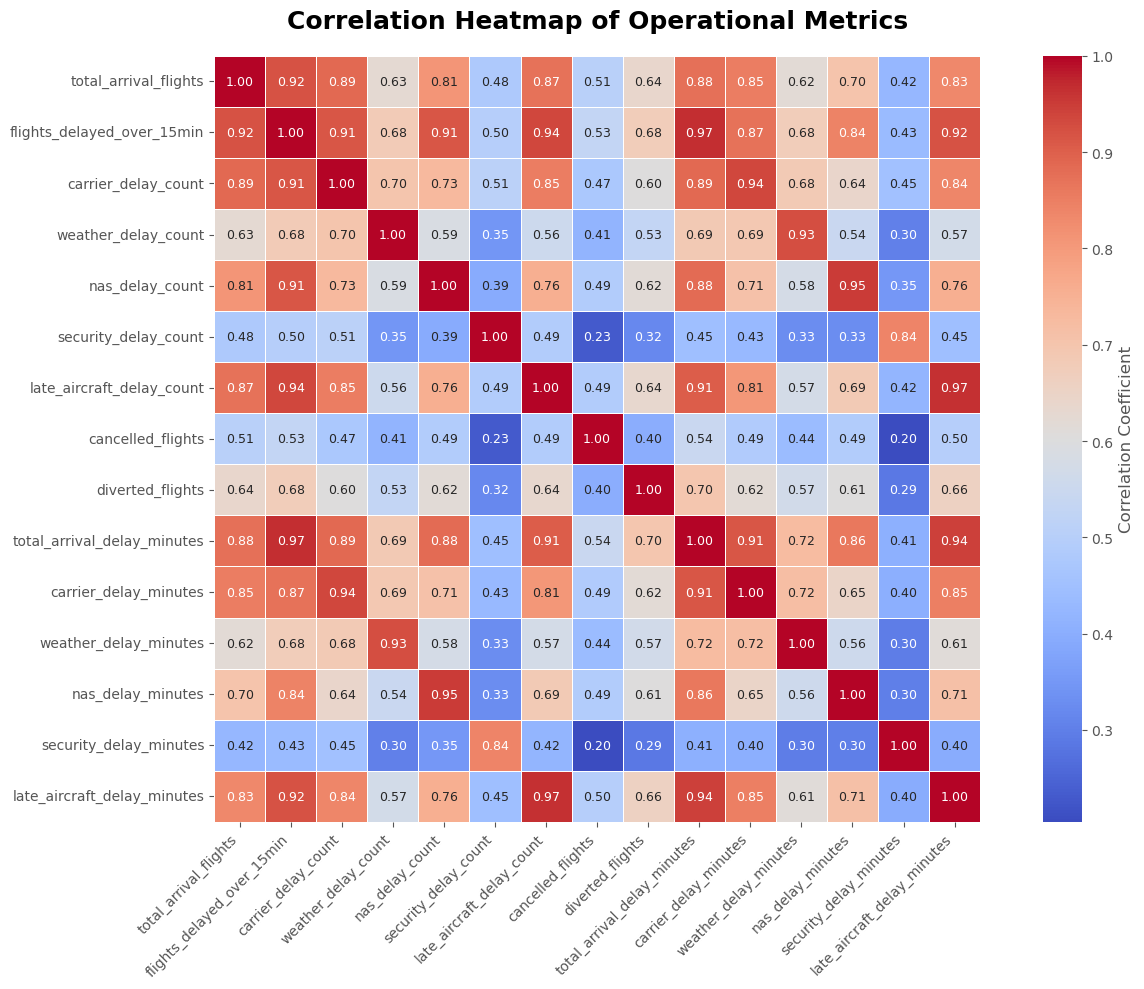

In [45]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation Coefficient"},
    annot_kws={"size": 9}
)

plt.title("Correlation Heatmap of Operational Metrics",
          fontsize=18,
          fontweight="bold",
          pad=20)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.show()

### Key Findings

- **Total arrival delay minutes** have a very strong positive correlation with **flights delayed over 15 minutes** (0.97), indicating that an increase in delayed flights significantly increases total delay time.

- **Late aircraft delay minutes** (0.94) and **carrier delay minutes** (0.91) exhibit the strongest relationships with total arrival delay minutes, making them the primary contributors to overall flight delays.

- **Weather delay count** and **weather delay minutes** are highly correlated (0.93), while **NAS delay count** and **NAS delay minutes** show an even stronger relationship (0.95). This demonstrates consistency between delay occurrences and their duration.

- **Security-related delays** show comparatively weaker correlations with most operational metrics, suggesting they contribute less frequently to overall airline delays.

# 12. Conclusion


This exploratory data analysis examined airline operational performance using historical flight delay data from 2003 to 2024. The analysis explored traffic trends, airline performance, airport performance, delay causes, seasonal patterns, and relationships among operational metrics.

The findings indicate that flight delays are primarily influenced by carrier operations and late aircraft delays, while weather and National Airspace System (NAS) delays also contribute significantly during certain periods. Airport traffic volume and seasonal demand further affect operational performance.

Overall, the analysis provides a strong understanding of the factors affecting airline delays and establishes a solid foundation for feature engineering, predictive modeling, and business decision-making in the next stages of the project.